## **Analisis exploratorio**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [9]:
USUARIO = "postgres"
PASSWORD = "1028"
HOST = "localhost"
PUERTO = "5432"
BASE_DATOS = "dw_analisis_criminalidad"

engine = create_engine(
    f"postgresql+psycopg2://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}"
)

print("Conexión creada correctamente.")

Conexión creada correctamente.


#### **1. Distribución de los tipos de delito entre los departamentos de Colombia**

In [10]:
query = """
    SELECT
        u.departamento,
        d.tipo_delito,
        SUM(f.cantidad_delitos) AS cantidad_delitos
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    INNER JOIN dim_delito AS d
        ON f.id_delito = d.id_delito
    GROUP BY u.departamento, d.tipo_delito
    ORDER BY u.departamento, cantidad_delitos DESC;
"""

df_departamento_delito = pd.read_sql(query, engine)
df_departamento_delito.head()

,departamento,tipo_delito,cantidad_delitos
0,Amazonas,Lesiones personales,2567
1,Amazonas,Violencia intrafamiliar,1099
2,Amazonas,Delitos sexuales,849
3,Amazonas,Hurto a residencias y entidades comerciales,802
4,Amazonas,Amenazas,732


**Distribucion por tipo de delito**

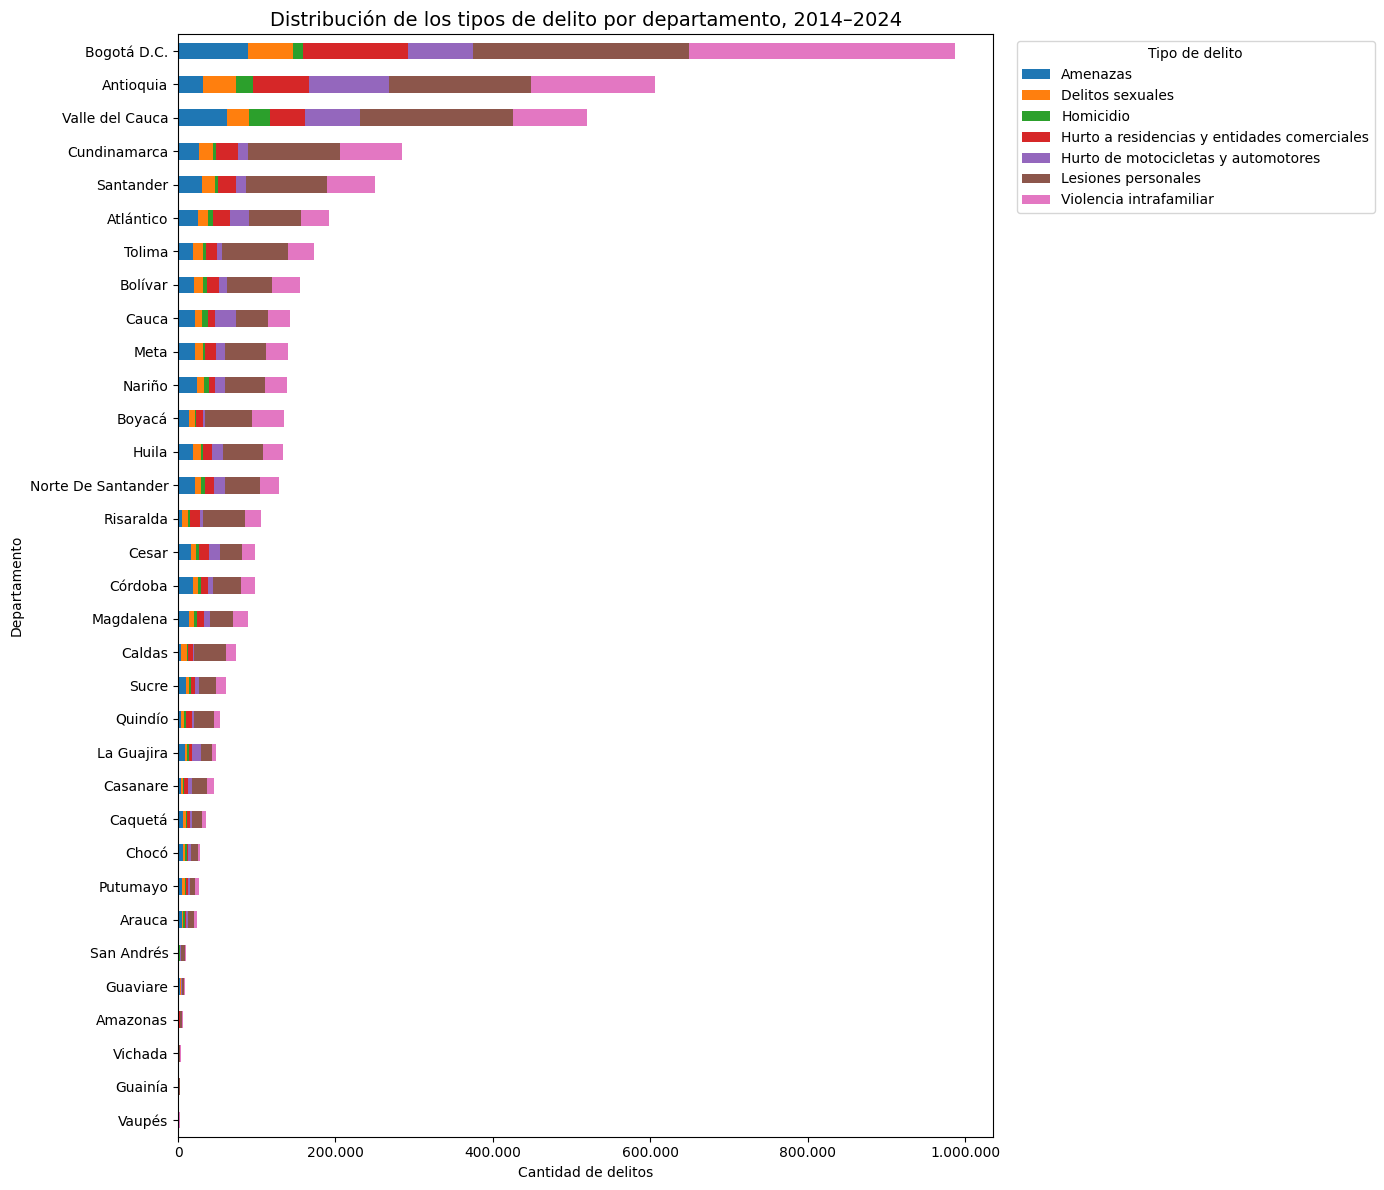

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Matriz departamento × tipo de delito
tabla_departamento_delito = (
    df_departamento_delito
    .pivot(
        index="departamento",
        columns="tipo_delito",
        values="cantidad_delitos"
    )
    .fillna(0)
)

# Ordenar departamentos de mayor a menor cantidad total
tabla_departamento_delito = tabla_departamento_delito.loc[
    tabla_departamento_delito.sum(axis=1)
    .sort_values(ascending=True)
    .index
]

# Crear figura
fig, ax = plt.subplots(figsize=(14, 12))

# Gráfico de barras apiladas
tabla_departamento_delito.plot(
    kind="barh",
    stacked=True,
    ax=ax
)

# Títulos y etiquetas
ax.set_title(
    "Distribución de los tipos de delito por departamento, 2014–2024",
    fontsize=14
)

ax.set_xlabel("Cantidad de delitos")
ax.set_ylabel("Departamento")

# Formato del eje X
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

# Leyenda
ax.legend(
    title="Tipo de delito",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
tabla_departamento_delito

**Participación de cada delito dentro de cada territorio**

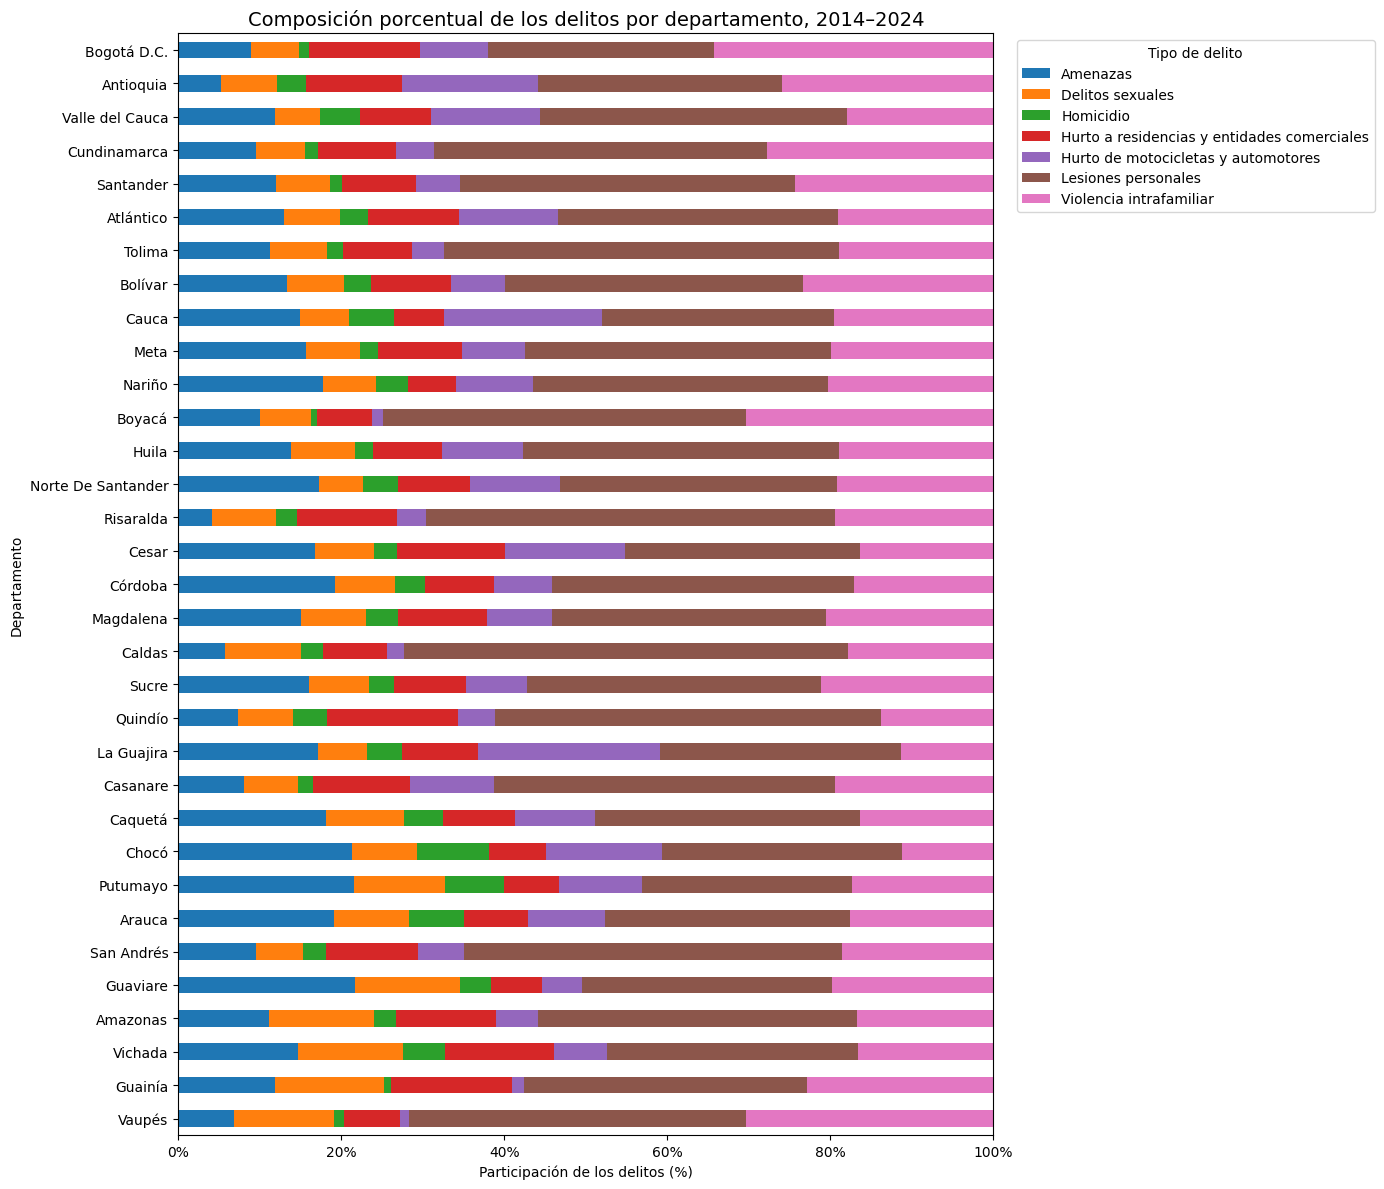

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Participación porcentual de cada delito dentro de cada departamento
tabla_porcentajes = (
    tabla_departamento_delito
    .div(
        tabla_departamento_delito.sum(axis=1),
        axis=0
    ) * 100
)

# Ordenar igual que la figura de cantidades:
# mayor volumen total arriba
orden_departamentos = (
    tabla_departamento_delito
    .sum(axis=1)
    .sort_values(ascending=True)
    .index
)

tabla_porcentajes = tabla_porcentajes.loc[orden_departamentos]

# Figura
fig, ax = plt.subplots(figsize=(14, 12))

tabla_porcentajes.plot(
    kind="barh",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Composición porcentual de los delitos por departamento, 2014–2024",
    fontsize=14
)

ax.set_xlabel("Participación de los delitos (%)")
ax.set_ylabel("Departamento")

ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlim(0, 100)

ax.legend(
    title="Tipo de delito",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
tabla_porcentajes

In [13]:
print("Total de delitos:", df_departamento_delito["cantidad_delitos"].sum())
print("Departamentos:", df_departamento_delito["departamento"].nunique())
print("Tipos de delito:", df_departamento_delito["tipo_delito"].nunique())

Total de delitos: 4805136
Departamentos: 33
Tipos de delito: 7


In [14]:
orden_departamentos = (
    tabla_departamento_delito
    .sum(axis=1)
    .sort_values(ascending=False)
    .index
)

tabla_departamento_delito_ordenada = (
    tabla_departamento_delito
    .loc[orden_departamentos]
)

tabla_departamento_delito_ordenada

tipo_delito,Amenazas,Delitos sexuales,Homicidio,Hurto a residencias y entidades comerciales,Hurto de motocicletas y automotores,Lesiones personales,Violencia intrafamiliar
departamento,,,,,,,
Bogotá D.C.,88405,57373,12652,133960,82615,273862,337608
Antioquia,32019,41389,21886,71160,100928,180781,157423
Valle del Cauca,61631,28505,26080,44674,69985,195098,93524
Cundinamarca,27146,17171,4546,27007,13463,116046,78945
Santander,30198,16506,3524,23003,13464,102781,61063
Atlántico,25021,13119,6772,21248,23417,66167,36567
Tolima,19555,12014,3477,14557,6797,83762,32860
Bolívar,20646,10850,5187,15265,10141,56682,36131
Cauca,21230,8676,7783,8822,27500,40563,27773
